In [13]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(np.uint8)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)

In [14]:
from sklearn.linear_model import SGDClassifier

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

print(confusion_matrix(y_train_5, y_train_pred))
print("Precision:", precision_score(y_train_5, y_train_pred))
print("Recall:", recall_score(y_train_5, y_train_pred))
print("F1 Score:", f1_score(y_train_5, y_train_pred))


[[54103   521]
 [ 1579  3797]]
Precision: 0.8793422880963409
Recall: 0.7062872023809523
F1 Score: 0.783371157416959


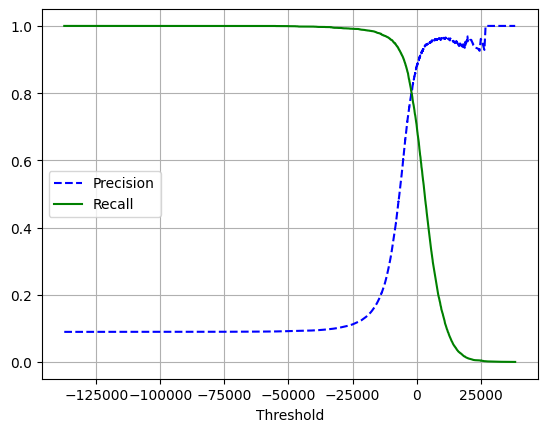

In [16]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

def plot_precision_recall_vs_threshold():
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend()
    plt.grid()
    plt.show()

plot_precision_recall_vs_threshold()


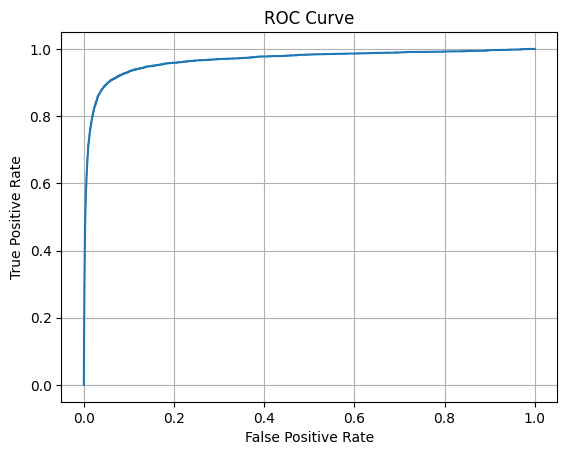

AUC Score: 0.9667375476090224


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid()
plt.show()

print("AUC Score:", roc_auc_score(y_train_5, y_scores))


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
X_test_scaled = scaler.transform(X_test.astype(np.float64))

log_clf = LogisticRegression(solver="lbfgs", max_iter=3000)
log_clf.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


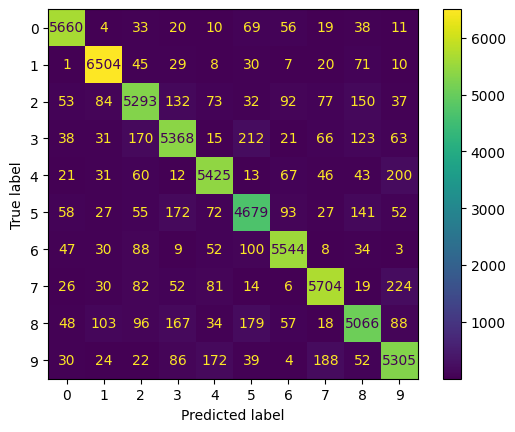

In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Build pipeline: Scaling + Logistic Regression
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='lbfgs', max_iter=5000)
)

# Use pipeline in cross_val_predict
y_pred = cross_val_predict(pipeline, X_train, y_train, cv=3)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_train, y_pred)
plt.show()


In [24]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier

# Define multilabels: [is large (>=7), is odd]
y_multilabel = np.c_[(y_train >= 7), (y_train % 2 == 1)]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
import numpy as np

# Add noise
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
X_test_mod = X_test + np.random.randint(0, 100, (len(X_test), 784))

# Targets are the clean images
y_train_mod = X_train
y_test_mod = X_test

knn_cleaner = KNeighborsClassifier()
knn_cleaner.fit(X_train_mod, y_train_mod)

# Predict clean image from noisy one
clean_digit = knn_cleaner.predict([X_test_mod[0]])


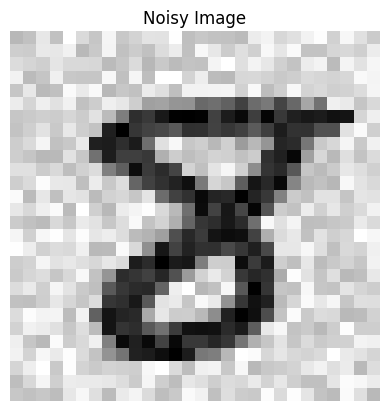

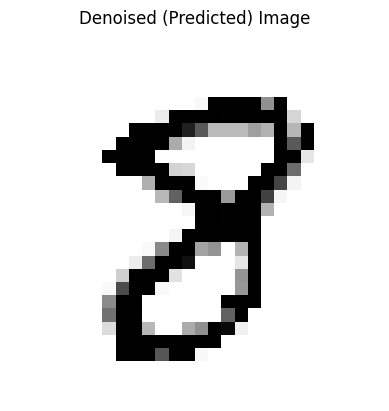

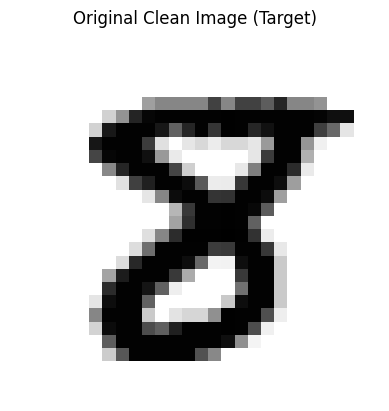

In [26]:
import matplotlib.pyplot as plt

# Show noisy image
def show_image(data, title="Image"):
    plt.imshow(data.reshape(28, 28), cmap="binary")
    plt.title(title)
    plt.axis("off")
    plt.show()

# Visualize input and output
index = 0
noisy_image = X_test_mod[index]
cleaned_image = clean_digit[0]

show_image(noisy_image, "Noisy Image")
show_image(cleaned_image, "Denoised (Predicted) Image")
show_image(X_test[index], "Original Clean Image (Target)")


In [27]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(X_test[index], cleaned_image)
print("MSE for denoising:", mse)


MSE for denoising: 3879.184948979592


In [34]:
from joblib import dump

dump(knn_cleaner, "knn_cleaner_model.joblib")
print("✅ Model trained and saved as knn_cleaner_model.joblib")

✅ Model trained and saved as knn_cleaner_model.joblib
